This notebook evaluates the performance of hybrid retriever and shows the best performing hybrid variant against all the alpha values

Loaded beir/arguana
Docs: 8674, Queries: 1406

📊 Hybrid Evaluation Leaderboard for BEIR/ARGUANA:
                                 run_file  nDCG@10   MRR@10  Precision@10  Recall@100  MAP@1000
run_hybrid_zscore_a0.20_beir_arguana.trec 0.373511 0.247321      0.077169    0.939545  0.273355
run_hybrid_minmax_a0.40_beir_arguana.trec 0.373331 0.246553      0.077383    0.963727  0.266197
run_hybrid_minmax_a0.30_beir_arguana.trec 0.373080 0.246603      0.077240    0.964438  0.266039
run_hybrid_zscore_a0.30_beir_arguana.trec 0.372714 0.246518      0.077098    0.943101  0.271597
run_hybrid_zscore_a0.10_beir_arguana.trec 0.372009 0.246872      0.076671    0.935989  0.274220
run_hybrid_minmax_a0.20_beir_arguana.trec 0.371954 0.247067      0.076529    0.964438  0.267181
run_hybrid_minmax_a0.10_beir_arguana.trec 0.371902 0.246915      0.076600    0.964438  0.266853
              run_dense_beir_arguana.trec 0.371503 0.247712      0.076102    0.962304  0.268548
  run_hybrid_rank_a0.00_beir_arguana.tr

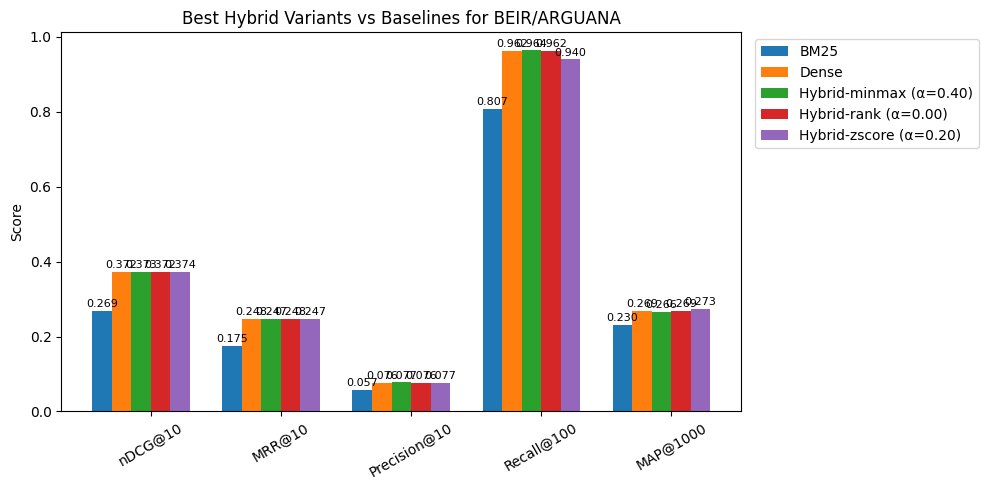

In [4]:
# ==========================================
# 📘 evaluate_hybrid_runs.ipynb
# ==========================================
import os
import ir_datasets
import numpy as np
import math
from collections import defaultdict
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------
# Config
# -------------------------------
RUNS_DIR = "./runs"
DATASET_NAME = "beir/arguana"
EVAL_K = 10
RECALL_K = 100
MAP_K = 1000

# Load the dataset
dataset = ir_datasets.load(DATASET_NAME)
print(f"Loaded {DATASET_NAME}")
print(f"Docs: {dataset.docs_count()}, Queries: {dataset.queries_count()}")
qrels = {}
for r in dataset.qrels_iter():
    qrels.setdefault(str(r.query_id), {})[str(r.doc_id)] = int(r.relevance)

# -------------------------------
# Metric functions
# -------------------------------
def mrr_at_k(run, qrels, k=10):
    mrrs = []
    for qid, ranked in run.items():
        relset = qrels.get(qid, {})
        rr = 0.0
        for i, (docid, _) in enumerate(ranked[:k], start=1):
            if relset.get(docid, 0) > 0:
                rr = 1.0 / i
                break
        mrrs.append(rr)
    return float(np.mean(mrrs)) if mrrs else 0.0

def ndcg_at_k(run, qrels, k=10):
    def dcg(rels): return sum(rel / math.log2(i + 2) for i, rel in enumerate(rels))
    vals = []
    for qid, ranked in run.items():
        rels = [1 if qrels.get(qid, {}).get(docid, 0) > 0 else 0 for docid, _ in ranked[:k]]
        idcg = dcg(sorted(rels, reverse=True))
        vals.append((dcg(rels) / idcg) if idcg > 0 else 0.0)
    return float(np.mean(vals)) if vals else 0.0

def precision_at_k(run, qrels, k=10):
    precisions = []
    for qid, ranked in run.items():
        rels = [1 if qrels.get(qid, {}).get(docid, 0) > 0 else 0 for docid, _ in ranked[:k]]
        precisions.append(sum(rels) / len(rels) if rels else 0)
    return float(np.mean(precisions)) if precisions else 0.0

def recall_at_k(run, qrels, k=100):
    recalls = []
    for qid, ranked in run.items():
        relset = qrels.get(qid, {})
        total_rel = len([d for d in relset if relset[d] > 0])
        if total_rel == 0:
            continue
        rels = [1 if relset.get(docid, 0) > 0 else 0 for docid, _ in ranked[:k]]
        recalls.append(sum(rels) / total_rel)
    return float(np.mean(recalls)) if recalls else 0.0

def map_at_k(run, qrels, k=1000):
    ap_scores = []
    for qid, ranked in run.items():
        relset = qrels.get(qid, {})
        num_rel = 0
        score = 0.0
        for i, (docid, _) in enumerate(ranked[:k], start=1):
            if relset.get(docid, 0) > 0:
                num_rel += 1
                score += num_rel / i
        if num_rel > 0:
            ap_scores.append(score / num_rel)
    return float(np.mean(ap_scores)) if ap_scores else 0.0


# -------------------------------
# TREC Reader
# -------------------------------
def read_trec(path):
    per_q = defaultdict(list)
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 6:
                continue
            qid, _, docid, _rank, score, _sys = parts[:6]
            per_q[qid].append((docid, float(score)))
    for qid in per_q:
        per_q[qid].sort(key=lambda x: x[1], reverse=True)
    return per_q


# -------------------------------
# Evaluation function
# -------------------------------
def evaluate_run(run_dict, qrels):
    return {
        "nDCG@10": ndcg_at_k(run_dict, qrels, k=EVAL_K),
        "MRR@10": mrr_at_k(run_dict, qrels, k=EVAL_K),
        "Precision@10": precision_at_k(run_dict, qrels, k=EVAL_K),
        "Recall@100": recall_at_k(run_dict, qrels, k=RECALL_K),
        "MAP@1000": map_at_k(run_dict, qrels, k=MAP_K)
    }


# -------------------------------
# Evaluate all hybrid runs for this dataset
# -------------------------------
def evaluate_all_for_dataset(qrels, dataset_name=DATASET_NAME):
    suffix = f"_{dataset_name.replace('/', '_')}.trec"
    results = []

    for file in sorted(os.listdir(RUNS_DIR)):
        if not file.endswith(suffix):
            continue
        path = os.path.join(RUNS_DIR, file)
        run = read_trec(path)
        metrics = evaluate_run(run, qrels)
        results.append({"run_file": file, **metrics})

    df = pd.DataFrame(results)
    df["norm"] = df["run_file"].str.extract(r"run_hybrid_(\w+)_")
    df["alpha"] = df["run_file"].str.extract(r"_a([0-9]+\.[0-9]+)_")

    # sort descending by nDCG@10
    df = df.sort_values("nDCG@10", ascending=False).reset_index(drop=True)

    print(f"\n📊 Hybrid Evaluation Leaderboard for {dataset_name.upper()}:")
    print(df[["run_file", "nDCG@10", "MRR@10", "Precision@10", "Recall@100", "MAP@1000"]].to_string(index=False))

    # find best per normalization
    best_per_norm = df.loc[df.groupby("norm")["nDCG@10"].idxmax()]
    print("\n🏆 Best-performing hybrid per normalization:")
    print(best_per_norm[["norm", "alpha", "nDCG@10", "MRR@10", "Precision@10", "Recall@100", "MAP@1000"]])

    return df, best_per_norm


# -------------------------------
# Visualization
# -------------------------------
def plot_best_vs_baselines(bm25_path, dense_path, qrels, best_per_norm, dataset_name=DATASET_NAME):
    bm25 = read_trec(bm25_path)
    dense = read_trec(dense_path)

    bm25_metrics = evaluate_run(bm25, qrels)
    dense_metrics = evaluate_run(dense, qrels)

    # collect best hybrid variants
    systems = ["BM25", "Dense"]
    metrics_list = [bm25_metrics, dense_metrics]

    for _, row in best_per_norm.iterrows():
        systems.append(f"Hybrid-{row['norm']} (α={row['alpha']})")
        metrics_list.append({
            "nDCG@10": row["nDCG@10"],
            "MRR@10": row["MRR@10"],
            "Precision@10": row["Precision@10"],
            "Recall@100": row["Recall@100"],
            "MAP@1000": row["MAP@1000"],
        })

    metrics = list(metrics_list[0].keys())
    vals = np.array([[m[k] for k in metrics] for m in metrics_list])

    x = np.arange(len(metrics))
    width = 0.15
    fig, ax = plt.subplots(figsize=(10, 5))

    for i, sys in enumerate(systems):
        ax.bar(x + (i - len(systems)/2) * width, vals[i], width, label=sys)

    ax.set_ylabel("Score")
    ax.set_title(f"Best Hybrid Variants vs Baselines for {dataset_name.upper()}")
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=30)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")

    # add values
    for i in range(len(systems)):
        for j in range(len(metrics)):
            ax.text(x[j] + (i - len(systems)/2)*width, vals[i, j] + 0.005,
                    f"{vals[i, j]:.3f}", ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()


# -------------------------------
# 🧪 Usage Example
# -------------------------------
# Load qrels from ir_datasets
# qrels = {}
# for r in dataset.qrels_iter():
#     qrels.setdefault(str(r.query_id), {})[str(r.doc_id)] = int(r.relevance)

bm25_path = os.path.join(RUNS_DIR, f"run_bm25_{DATASET_NAME.replace('/', '_')}.trec")
dense_path = os.path.join(RUNS_DIR, f"run_dense_{DATASET_NAME.replace('/', '_')}.trec")

df, best_per_norm = evaluate_all_for_dataset(qrels, DATASET_NAME)
plot_best_vs_baselines(bm25_path, dense_path, qrels, best_per_norm, DATASET_NAME)
